In [1]:
%pip install scikit-learn matplotlib pandas

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
df = pd.read_csv("cleaned_data.csv")
df.head()

,student_id,age,city_tier,college_tier,cgpa,backlog_history,attendance_percentage,DSA_problems_solved,GitHub_repos,hackathons_participated,...,branch_Electronics,branch_Information Technology,branch_Mechanical,degree_BTech,degree_MCA,primary_language_Go,primary_language_Java,primary_language_JavaScript,primary_language_Python,primary_language_Rust
0,STU00001,22,1,2,6.71,3,75.5,656,10.0,2,...,False,False,False,False,True,False,False,False,False,False
1,STU00002,20,2,3,6.14,0,84.4,619,16.0,1,...,False,False,False,True,False,False,False,False,False,True
2,STU00003,23,3,2,7.11,0,80.6,674,30.0,3,...,False,False,False,True,False,False,True,False,False,False
3,STU00004,25,2,3,7.41,0,69.2,637,15.0,3,...,False,False,False,True,False,False,False,False,False,True
4,STU00005,25,3,3,8.29,0,76.6,986,12.0,0,...,False,False,False,False,False,False,True,False,False,False


In [3]:
df.columns

Index(['student_id', 'age', 'city_tier', 'college_tier', 'cgpa',
       'backlog_history', 'attendance_percentage', 'DSA_problems_solved',
       'GitHub_repos', 'hackathons_participated', 'development_projects_count',
       'AI_ML_projects', 'internships_completed', 'resume_score',
       'communication_skills', 'aptitude_score', 'mock_interview_score',
       'sleep_hours', 'screen_time', 'gaming_hours', 'study_hours_daily',
       'stress_level', 'burnout_score', 'gym_frequency', 'family_income_lpa',
       'self_learning_hours', 'motivation_level', 'placement_status',
       'company_type', 'work_mode', 'salary_lpa', 'interview_rounds_cleared',
       'offer_count', 'joining_delay_months', 'layoffs_risk_score',
       'AI_tool_usage_frequency', 'prompt_engineering_skill', 'AI_fear_score',
       'adaptability_score', 'placement_binary', 'gender_Male', 'gender_Other',
       'state_Gujarat', 'state_Karnataka', 'state_Maharashtra',
       'state_Tamil Nadu', 'state_Telangana', 'stat

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 61 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     25000 non-null  str    
 1   age                            25000 non-null  int64  
 2   city_tier                      25000 non-null  int64  
 3   college_tier                   25000 non-null  int64  
 4   cgpa                           25000 non-null  float64
 5   backlog_history                25000 non-null  int64  
 6   attendance_percentage          25000 non-null  float64
 7   DSA_problems_solved            25000 non-null  int64  
 8   GitHub_repos                   25000 non-null  float64
 9   hackathons_participated        25000 non-null  int64  
 10  development_projects_count     25000 non-null  int64  
 11  AI_ML_projects                 25000 non-null  int64  
 12  internships_completed          25000 non-null  int64  
 1

In [5]:
X = df.drop(columns=[
    'placement_binary',
    'placement_status',
    'student_id',
    'company_type',
    'work_mode',
    'salary_lpa',
    'offer_count',
    'joining_delay_months',
    'interview_rounds_cleared'
])

y = df['placement_binary']

In [6]:
print(X.shape)
print(y.shape)

(25000, 52)
(25000,)


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [8]:
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (20000, 52)
Testing features: (5000, 52)
Training target: (20000,)
Testing target: (5000,)


In [9]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [10]:
y_pred = model.predict(X_test)

In [11]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


layoffs_risk_score          0.095233
cgpa                        0.072650
DSA_problems_solved         0.061514
resume_score                0.035566
burnout_score               0.034894
motivation_level            0.031532
adaptability_score          0.030880
prompt_engineering_skill    0.030814
sleep_hours                 0.030811
stress_level                0.030146
dtype: float64


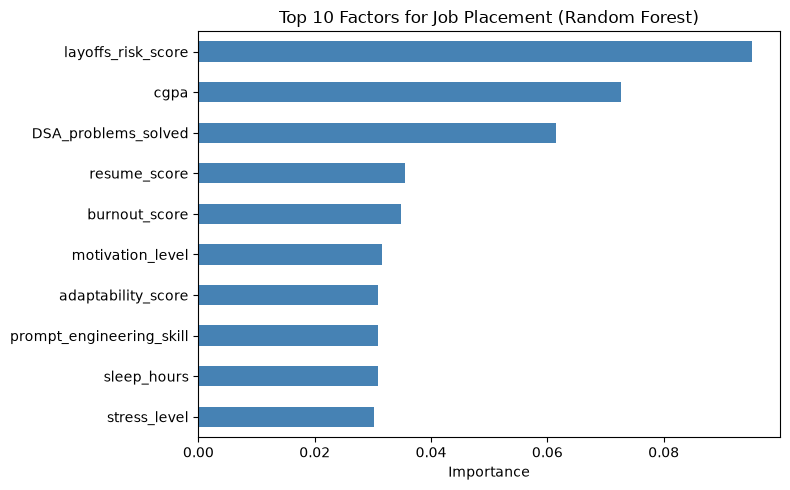

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(model.feature_importances_, index=X.columns)
top10 = importances.sort_values(ascending=False).head(10)

print(top10)

plt.figure(figsize=(8,5))
top10.plot(kind='barh', color='steelblue')
plt.title('Top 10 Factors for Job Placement (Random Forest)')
plt.xlabel('Importance')
plt.gca().invert_yaxis()  # highest importance on top
plt.tight_layout()
plt.savefig('placement_importance_rf.png', dpi=150)
plt.show()

In [13]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.984
Confusion Matrix:
[[   1   80]
 [   0 4919]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.01      0.02        81
           1       0.98      1.00      0.99      4919

    accuracy                           0.98      5000
   macro avg       0.99      0.51      0.51      5000
weighted avg       0.98      0.98      0.98      5000



# Random Forest Classification (Balanced) - this model uses class_weight = balanced to focus more on the minority class which are the students that were not placed

In [14]:
from sklearn.ensemble import RandomForestClassifier

balanced_model = RandomForestClassifier(
    random_state=42,
    class_weight='balanced'
)

In [15]:
balanced_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.

In [16]:
balanced_pred = balanced_model.predict(X_test)

In [17]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Balanced Model Accuracy:", accuracy_score(y_test, balanced_pred))

print("\nBalanced Confusion Matrix:")
print(confusion_matrix(y_test, balanced_pred))

print("\nBalanced Classification Report:")
print(classification_report(y_test, balanced_pred))

Balanced Model Accuracy: 0.984

Balanced Confusion Matrix:
[[   5   76]
 [   4 4915]]

Balanced Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.06      0.11        81
           1       0.98      1.00      0.99      4919

    accuracy                           0.98      5000
   macro avg       0.77      0.53      0.55      5000
weighted avg       0.98      0.98      0.98      5000



# Logistic Regression

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Logistic Regression needs scaled features (Random Forest didn't)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logreg_model = LogisticRegression(max_iter=1000, class_weight='balanced')
logreg_model.fit(X_train_scaled, y_train)

logreg_pred = logreg_model.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, logreg_pred))
print("\nLogistic Regression Confusion Matrix:")
print(confusion_matrix(y_test, logreg_pred))
print("\nLogistic Regression Classification Report:")
print(classification_report(y_test, logreg_pred))

Logistic Regression Accuracy: 0.8576

Logistic Regression Confusion Matrix:
[[  67   14]
 [ 698 4221]]

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.09      0.83      0.16        81
           1       1.00      0.86      0.92      4919

    accuracy                           0.86      5000
   macro avg       0.54      0.84      0.54      5000
weighted avg       0.98      0.86      0.91      5000



Top 10 factors INCREASING placement likelihood:
internships_completed      1.306722
cgpa                       0.991261
DSA_problems_solved        0.706746
GitHub_repos               0.562061
communication_skills       0.332301
motivation_level           0.223812
branch_Computer Science    0.215934
aptitude_score             0.192575
AI_ML_projects             0.157176
self_learning_hours        0.154018
dtype: float64

Top 10 factors DECREASING placement likelihood:
layoffs_risk_score        -1.438970
state_West Bengal         -0.349489
burnout_score             -0.340880
backlog_history           -0.264323
primary_language_Python   -0.193569
state_Telangana           -0.182073
adaptability_score        -0.133233
hackathons_participated   -0.124330
gym_frequency             -0.111139
AI_tool_usage_frequency   -0.107505
dtype: float64


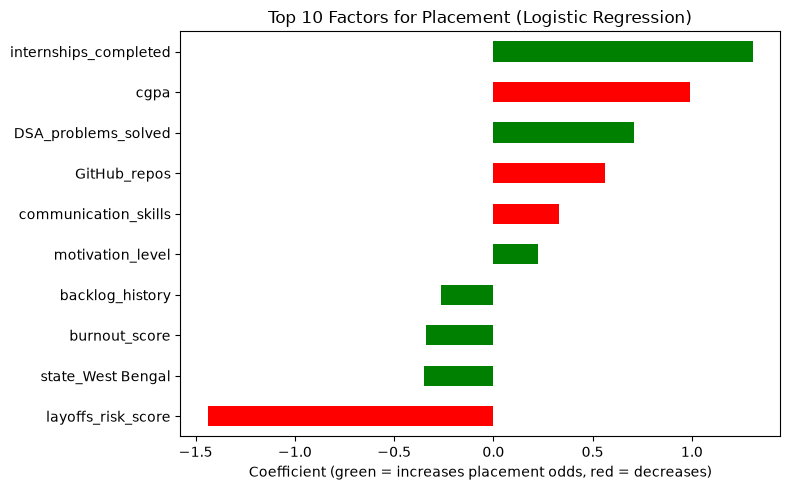

In [19]:
coefs = pd.Series(logreg_model.coef_[0], index=X.columns)

print("Top 10 factors INCREASING placement likelihood:")
print(coefs.sort_values(ascending=False).head(10))
print("\nTop 10 factors DECREASING placement likelihood:")
print(coefs.sort_values().head(10))

top10_abs = coefs.reindex(coefs.abs().sort_values(ascending=False).head(10).index)

plt.figure(figsize=(8,5))
colors = ['green' if v > 0 else 'red' for v in top10_abs]
top10_abs.sort_values().plot(kind='barh', color=colors)
plt.title('Top 10 Factors for Placement (Logistic Regression)')
plt.xlabel('Coefficient (green = increases placement odds, red = decreases)')
plt.tight_layout()
plt.savefig('placement_importance_logreg.png', dpi=150)
plt.show()

In [20]:
comparison = pd.DataFrame({
    'Model': ['Random Forest', 'Random Forest (balanced)', 'Logistic Regression (balanced)'],
    'Accuracy': [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, balanced_pred),
        accuracy_score(y_test, logreg_pred)
    ],
})
print(comparison)

                            Model  Accuracy
0                   Random Forest    0.9840
1        Random Forest (balanced)    0.9840
2  Logistic Regression (balanced)    0.8576


**Conclusion:** Random Forest achieved the highest raw accuracy but almost completely failed to identify Not-Placed students (recall as low as 1-6%). Logistic Regression 
traded some overall accuracy.